<a href="https://colab.research.google.com/github/kk698334/-Streaming-algorithm-comparison-experiment/blob/main/Streaming_algorithm_comparison_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import urllib.request
import zipfile
import os

# 데이터셋 다운로드 경로
url = 'https://files.grouplens.org/datasets/movielens/ml-1m.zip'
file_name = 'ml-1m.zip'

if not os.path.exists(file_name):
    print("데이터셋 다운로드 중...")
    urllib.request.urlretrieve(url, file_name)
    print("압축 해제 중...")
    with zipfile.ZipFile(file_name, 'r') as zip_ref:
        zip_ref.extractall('.')
    print("데이터 준비 완료! 경로: ml-1m/ratings.dat")
else:
    print("데이터가 이미 존재합니다.")

데이터가 이미 존재합니다.


In [ ]:
import sys
import time

def stream_ratings(file_path):
    """
    파일을 한 번에 읽지 않고 한 줄씩 스트리밍 방식으로 반환하는 제너레이터
    """
    # MovieLens ratings.dat 포맷: UserID::MovieID::Rating::Timestamp
    with open(file_path, 'r', encoding='latin-1') as f:
        for line in f:
            parts = line.strip().split('::')
            # 반환: user_id, movie_id
            yield int(parts[0]), int(parts[1])

# 스트리밍이 잘 되는지 첫 3줄만 테스트
print("스트리밍 테스트:")
stream_gen = stream_ratings('ml-1m/ratings.dat')
for i in range(3):
    print(next(stream_gen))

스트리밍 테스트:
(1, 1193)
(1, 661)
(1, 914)


In [ ]:
import hashlib

def get_hash(item, seed, max_val):
    """
    아이템과 시드(seed)를 조합하여 해시값을 생성하고, 배열 크기(max_val) 내의 인덱스를 반환
    """
    # 아이템과 시드(해시 함수 번호)를 조합하여 문자열 생성
    hash_str = f"{seed}_{item}"
    hash_obj = hashlib.md5(hash_str.encode())
    # 16진수 해시값을 정수로 변환 후 max_val로 나눈 나머지 반환
    return int(hash_obj.hexdigest(), 16) % max_val

In [ ]:
import math

class BloomFilter:
    def __init__(self, expected_items, fpr):
        """
        expected_items: 예상되는 총 원소의 수 (n)
        fpr: 허용할 False Positive Rate (목표 오차율, p)
        """
        self.expected_items = expected_items
        self.fpr = fpr

        # 1. 최적의 배열 크기(m)와 해시 함수 개수(k) 수학적 계산
        self.m = self._get_optimal_m(expected_items, fpr)
        self.k = self._get_optimal_k(self.m, expected_items)

        # 2. 비트 배열 생성 (메모리 절약을 위해 bytearray 사용, 1 byte = 8 bits)
        self.bit_array = bytearray(math.ceil(self.m / 8))

    def _get_optimal_m(self, n, p):
        # m = - (n * ln(p)) / (ln(2)^2)
        return int(- (n * math.log(p)) / (math.log(2) ** 2))

    def _get_optimal_k(self, m, n):
        # k = (m / n) * ln(2)
        return int((m / n) * math.log(2))

    def add(self, item):
        """원소를 Bloom Filter에 추가"""
        for i in range(self.k):
            index = get_hash(item, i, self.m)
            # 비트 단위 연산: 해당 인덱스의 비트를 1로 설정
            byte_idx = index // 8
            bit_idx = index % 8
            self.bit_array[byte_idx] |= (1 << bit_idx)

    def check(self, item):
        """원소가 포함되어 있는지 확인"""
        for i in range(self.k):
            index = get_hash(item, i, self.m)
            byte_idx = index // 8
            bit_idx = index % 8
            # 하나라도 0이면 절대 포함되지 않은 것 (Definite No)
            if not (self.bit_array[byte_idx] & (1 << bit_idx)):
                return False
        # 모두 1이면 포함되어 있을 확률이 높음 (False Positive 발생 가능성 존재)
        return True

    def get_memory_size(self):
        """실제 메모리 사용량 반환 (Bytes)"""
        return sys.getsizeof(self.bit_array)

print("Bloom Filter 클래스 정의 완료!")

Bloom Filter 클래스 정의 완료!


In [ ]:
import time
import sys

# 1. 실험 설정
file_path = 'ml-1m/ratings.dat'
total_records = 1000000    # 100만 건 전체 처리
expected_items = 1000000   # Bloom Filter 예상 아이템 수
target_fpr = 0.01          # 목표 False Positive Rate (1%)

bf = BloomFilter(expected_items=expected_items, fpr=target_fpr)
ground_truth_set = set()   # 정확한 정답지 역할

# 측정용 변수
false_positives = 0
true_negatives = 0
start_time = time.time()

# 2. 스트리밍 처리 시작
print("🚀 Bloom Filter 실험 시작... (약 10~20초 소요)")
stream_gen = stream_ratings(file_path)

for i, (user_id, movie_id) in enumerate(stream_gen):
    if i >= total_records:
        break

    # (유저, 영화) 조합을 하나의 고유 아이템으로 취급
    item_str = f"{user_id}_{movie_id}"

    # 1) 검사: 이미 처리된 데이터인지 확인
    in_bf = bf.check(item_str)
    in_gt = item_str in ground_truth_set

    # 2) 오차 판별
    if in_bf and not in_gt:
        false_positives += 1  # 블룸 필터는 있다고 했으나 실제론 없는 경우 (FPR)
    elif not in_bf and not in_gt:
        true_negatives += 1   # 올바르게 없다고 판단한 경우

    # 3) 데이터 추가
    bf.add(item_str)
    ground_truth_set.add(item_str)

    if (i + 1) % 250000 == 0:
        print(f"... {i + 1:,}건 처리 완료")

end_time = time.time()

# 3. 결과 분석 및 출력
processing_time = end_time - start_time
actual_fpr = false_positives / (false_positives + true_negatives) if (false_positives + true_negatives) > 0 else 0

gt_memory = sys.getsizeof(ground_truth_set)
bf_memory = bf.get_memory_size()

print("\n" + "="*50)
print("📊 [Bloom Filter 실험 결과]")
print(f"처리 데이터 수: {total_records:,} 건")
print(f"고유 아이템 수: {len(ground_truth_set):,} 건")
print("-" * 50)
print(f"⏱️ 시간: {processing_time:.2f} 초 (TPS: {total_records/processing_time:,.0f} 건/초)")
print(f"💾 메모리:")
print(f"   - Ground Truth (Set): {gt_memory:,} Bytes")
print(f"   - Bloom Filter:       {bf_memory:,} Bytes")
print(f"   👉 결과: 메모리를 약 {gt_memory/bf_memory:.1f}배 절약했습니다!")
print(f"🎯 정확도 (FPR):")
print(f"   - 목표 오차율: {target_fpr * 100:.2f} %")
print(f"   - 실제 오차율: {actual_fpr * 100:.4f} % (False Positives: {false_positives}건)")
print("="*50)

🚀 Bloom Filter 실험 시작... (약 10~20초 소요)
... 250,000건 처리 완료
... 500,000건 처리 완료
... 750,000건 처리 완료
... 1,000,000건 처리 완료

📊 [Bloom Filter 실험 결과]
처리 데이터 수: 1,000,000 건
고유 아이템 수: 1,000,000 건
--------------------------------------------------
⏱️ 시간: 16.40 초 (TPS: 60,966 건/초)
💾 메모리:
   - Ground Truth (Set): 33,554,648 Bytes
   - Bloom Filter:       1,198,190 Bytes
   👉 결과: 메모리를 약 28.0배 절약했습니다!
🎯 정확도 (FPR):
   - 목표 오차율: 1.00 %
   - 실제 오차율: 0.1831 % (False Positives: 1831건)


In [ ]:
class CountMinSketch:
    def __init__(self, epsilon, delta):
        """
        epsilon (허용 오차율): 클수록 너비(width)가 작아짐
        delta (실패 확률): 클수록 깊이(depth)가 작아짐
        """
        self.epsilon = epsilon
        self.delta = delta

        # 1. 최적의 너비(w)와 깊이(d) 계산
        self.width = math.ceil(math.e / epsilon)
        self.depth = math.ceil(math.log(1 / delta))

        # 2. 2차원 카운트 배열 생성 (0으로 초기화)
        self.table = [[0] * self.width for _ in range(self.depth)]

    def add(self, item, count=1):
        """아이템의 빈도수 증가"""
        for i in range(self.depth):
            index = get_hash(item, i, self.width)
            self.table[i][index] += count

    def estimate(self, item):
        """아이템의 추정 빈도수 반환 (각 해시 테이블 값 중 최솟값)"""
        min_count = float('inf')
        for i in range(self.depth):
            index = get_hash(item, i, self.width)
            min_count = min(min_count, self.table[i][index])
        return min_count

    def get_memory_size(self):
        """메모리 사용량 반환"""
        return sys.getsizeof(self.table) + sum(sys.getsizeof(row) for row in self.table)

print("Count-Min Sketch 클래스 정의 완료!")

Count-Min Sketch 클래스 정의 완료!


In [ ]:
# 1. 실험 설정
epsilon = 0.005 # 오차 0.5%
delta = 0.01    # 신뢰도 99% (오차를 벗어날 확률 1%)

cms = CountMinSketch(epsilon=epsilon, delta=delta)
ground_truth_dict = {} # 정확한 빈도수 저장 (딕셔너리)

start_time = time.time()
stream_gen = stream_ratings(file_path)

# 2. 스트리밍 처리 시작
print("🚀 Count-Min Sketch 실험 시작...")
for i, (_, movie_id) in enumerate(stream_gen):
    if i >= total_records:
        break

    # 스트리밍 실시간 업데이트
    cms.add(movie_id)
    ground_truth_dict[movie_id] = ground_truth_dict.get(movie_id, 0) + 1

    if (i + 1) % 250000 == 0:
        print(f"... {i + 1:,}건 처리 완료")

end_time = time.time()

# 3. 결과 분석
processing_time = end_time - start_time

# 오차율 계산 (평균 상대 오차)
total_relative_error = 0
for movie_id, actual_count in ground_truth_dict.items():
    estimated_count = cms.estimate(movie_id)
    error = abs(estimated_count - actual_count)
    total_relative_error += (error / actual_count)

mean_relative_error = total_relative_error / len(ground_truth_dict)

gt_memory = sys.getsizeof(ground_truth_dict)
cms_memory = cms.get_memory_size()

print("\n" + "="*50)
print("📊 [Count-Min Sketch 실험 결과]")
print(f"처리 데이터 수: {total_records:,} 건")
print(f"고유 영화 수: {len(ground_truth_dict):,} 개")
print("-" * 50)
print(f"⏱️ 시간: {processing_time:.2f} 초")
print(f"💾 메모리:")
print(f"   - Ground Truth (Dict): {gt_memory:,} Bytes")
print(f"   - CMS:                 {cms_memory:,} Bytes")
print(f"   👉 결과: 메모리를 약 {gt_memory/cms_memory:.1f}배 절약했습니다!")
print(f"🎯 정확도 (Mean Relative Error):")
print(f"   - 평균 상대 오차율: {mean_relative_error * 100:.4f} %")
print("="*50)

🚀 Count-Min Sketch 실험 시작...
... 250,000건 처리 완료
... 500,000건 처리 완료
... 750,000건 처리 완료
... 1,000,000건 처리 완료

📊 [Count-Min Sketch 실험 결과]
처리 데이터 수: 1,000,000 건
고유 영화 수: 3,706 개
--------------------------------------------------
⏱️ 시간: 9.25 초
💾 메모리:
   - Ground Truth (Dict): 147,544 Bytes
   - CMS:                 22,160 Bytes
   👉 결과: 메모리를 약 6.7배 절약했습니다!
🎯 정확도 (Mean Relative Error):
   - 평균 상대 오차율: 4665.3809 %


🚀 Bloom Filter 파라미터 비교 실험 시작...
목표 FPR: 10.0% -> 메모리: 119,871 Bytes, 실제 FPR: 3.050%
목표 FPR: 5.0% -> 메모리: 155,938 Bytes, 실제 FPR: 1.224%
목표 FPR: 1.0% -> 메모리: 239,684 Bytes, 실제 FPR: 0.169%
목표 FPR: 0.5% -> 메모리: 275,751 Bytes, 실제 FPR: 0.080%
목표 FPR: 0.1% -> 메모리: 359,497 Bytes, 실제 FPR: 0.009%


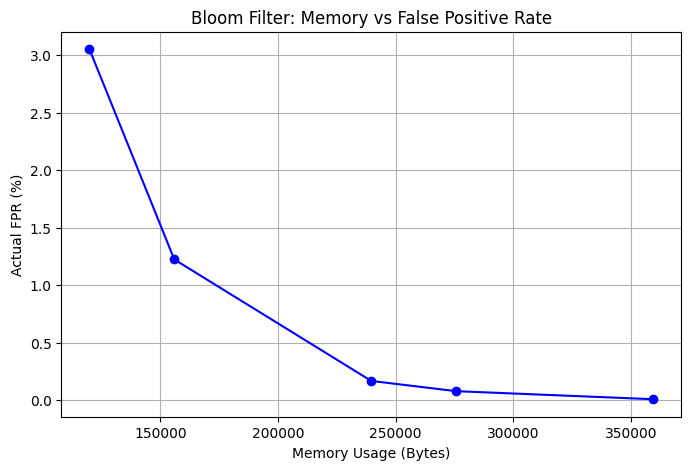

In [ ]:
import matplotlib.pyplot as plt

# 실험할 파라미터 (목표 FPR을 다르게 설정)
target_fprs = [0.1, 0.05, 0.01, 0.005, 0.001]
test_records = 200000

memory_sizes = []
actual_fprs = []

print("🚀 Bloom Filter 파라미터 비교 실험 시작...")

for fpr in target_fprs:
    bf = BloomFilter(expected_items=test_records, fpr=fpr)
    gt_set = set()

    fp_count = 0
    tn_count = 0

    stream_gen = stream_ratings(file_path)
    for i, (user_id, movie_id) in enumerate(stream_gen):
        if i >= test_records: break

        item_str = f"{user_id}_{movie_id}"
        in_bf = bf.check(item_str)
        in_gt = item_str in gt_set

        if in_bf and not in_gt: fp_count += 1
        elif not in_bf and not in_gt: tn_count += 1

        bf.add(item_str)
        gt_set.add(item_str)

    actual_fpr = fp_count / (fp_count + tn_count) if (fp_count + tn_count) > 0 else 0

    memory_sizes.append(bf.get_memory_size())
    actual_fprs.append(actual_fpr * 100) # 퍼센트로 변환
    print(f"목표 FPR: {fpr*100:.1f}% -> 메모리: {bf.get_memory_size():,} Bytes, 실제 FPR: {actual_fpr*100:.3f}%")

# 그래프 그리기
plt.figure(figsize=(8, 5))
plt.plot(memory_sizes, actual_fprs, marker='o', linestyle='-', color='b')
plt.title("Bloom Filter: Memory vs False Positive Rate")
plt.xlabel("Memory Usage (Bytes)")
plt.ylabel("Actual FPR (%)")
plt.grid(True)
plt.show()


🚀 Count-Min Sketch 파라미터 비교 실험 시작...
Epsilon: 0.05 -> 메모리: 2,600 Bytes, 평균 오차율: 34481.035%
Epsilon: 0.02 -> 메모리: 5,840 Bytes, 평균 오차율: 11829.345%
Epsilon: 0.01 -> 메모리: 11,280 Bytes, 평균 오차율: 4758.288%
Epsilon: 0.005 -> 메모리: 22,160 Bytes, 평균 오차율: 1658.386%
Epsilon: 0.002 -> 메모리: 54,800 Bytes, 평균 오차율: 261.381%


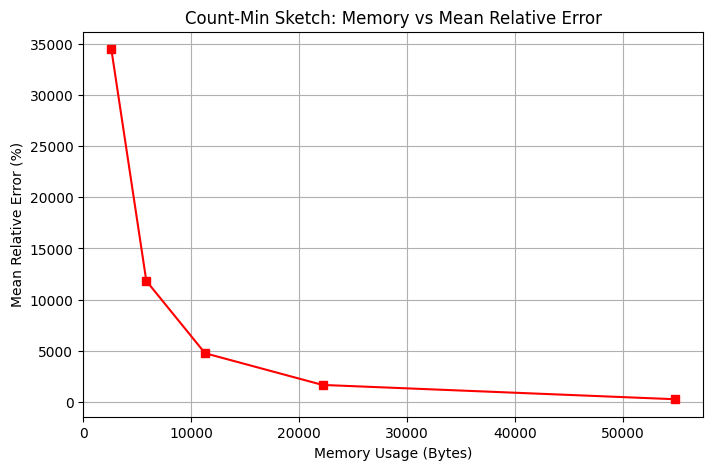

In [ ]:
# 실험할 파라미터 (허용 오차율 epsilon 변경)
epsilons = [0.05, 0.02, 0.01, 0.005, 0.002]
delta = 0.01

cms_memories = []
cms_errors = []

print("\n🚀 Count-Min Sketch 파라미터 비교 실험 시작...")

for eps in epsilons:
    cms = CountMinSketch(epsilon=eps, delta=delta)
    gt_dict = {}

    stream_gen = stream_ratings(file_path)
    for i, (_, movie_id) in enumerate(stream_gen):
        if i >= test_records: break

        cms.add(movie_id)
        gt_dict[movie_id] = gt_dict.get(movie_id, 0) + 1

    # 오차율 계산
    total_rel_error = 0
    for movie_id, actual_count in gt_dict.items():
        est_count = cms.estimate(movie_id)
        total_rel_error += abs(est_count - actual_count) / actual_count

    mean_error = (total_rel_error / len(gt_dict)) * 100 # 퍼센트로 변환

    cms_memories.append(cms.get_memory_size())
    cms_errors.append(mean_error)
    print(f"Epsilon: {eps} -> 메모리: {cms.get_memory_size():,} Bytes, 평균 오차율: {mean_error:.3f}%")

# 그래프 그리기
plt.figure(figsize=(8, 5))
plt.plot(cms_memories, cms_errors, marker='s', linestyle='-', color='r')
plt.title("Count-Min Sketch: Memory vs Mean Relative Error")
plt.xlabel("Memory Usage (Bytes)")
plt.ylabel("Mean Relative Error (%)")
plt.grid(True)
plt.show()